In [ ]:
# @title Initial Imports
!pip install -q ipywidgets reportlab
from google.colab import output
output.enable_custom_widget_manager()

import ipywidgets as widgets
from IPython.display import display

responses = {}  # shared across notebook

def ask_mcq(qid, question, options):
    # Create RadioButtons
    radio = widgets.RadioButtons(
        options=options,
        layout=widgets.Layout(width='auto'),
        style={'description_width': '0px'}
    )

    # Increase font size of options using custom CSS
    radio.add_class("big-radio")  # assign a class

    # Button and output
    btn = widgets.Button(description="Save answer", button_style='success')
    out = widgets.Output()

    def save_answer(b):
        responses[qid] = {
            "question": question,
            "selected": radio.value
        }
        with out:
            out.clear_output()
            print("✓ Saved")

    btn.on_click(save_answer)

    # Display question with bigger font
    display(widgets.HTML(f"<b style='font-size:24px'>{question}</b>"))
    display(radio, btn, out)

    # Inject CSS to enlarge radio button text
    display(widgets.HTML("""
    <style>
    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,
    .big-radio label {
        font-size: 20px !important;
    }
    </style>
    """))

# Consent Form / Pre-Survey

https://forms.office.com/Pages/ResponsePage.aspx?id=2wING578lUSVNx03nMoq5-3BxI6hVGxAlNsUatNmSW1URTBRUUZTVjhHT0pCRVlHUklNM0hVTFdHUy4u

# DFT · FFT · QFT: A Computational Framework

## Framework Overview

This notebook builds a direct path from the classical Discrete Fourier Transform (DFT) to the Quantum Fourier Transform (QFT), with the Fast Fourier Transform (FFT) serving as the bridge between them. The DFT is implemented as an explicit matrix–vector multiplication: the input signal is multiplied by a matrix whose entries are complex rotations (roots of unity), and the output is its frequency representation. The FFT does not change this matrix or its result just reorganizes the computation by factorizing the DFT matrix into smaller, repeated blocks, which is what reduces the cost from $O(N^2)$ to $O(N \log N)$. The QFT performs that exact same matrix operation on a quantum computer, replacing the classical even/odd splitting with a sequence of qubit operations and replacing the twiddle factor multiplications with controlled phase-shift gates. To make this correspondence concrete, the notebook traces a periodic signal through all three representations and shows that the same frequency structure appears in each case. The key insight throughout is that DFT, FFT, and QFT are not three different transforms they are three different ways to execute the same underlying computation.

---



---
## DFT Matrix


Imagine you record a piece of music. The sound wave is a list of numbers (amplitudes over time). The **Discrete Fourier Transform (DFT)** answers the question: *which frequencies make up this signal?*

Formally, given an input sequence $x_0, x_1, \ldots, x_{N-1}$, the DFT produces output frequencies $X_0, X_1, \ldots, X_{N-1}$ via:

$$X_k = \sum_{n=0}^{N-1} x_n \cdot \omega^{kn}, \qquad k = 0, 1, \ldots, N-1$$

where $\omega = e^{-2\pi i / N}$ is called a **root of unity**.

### What is a Root of Unity?

A root of unity is a complex number that, when raised to the power $N$, equals 1. Geometrically, these are evenly-spaced points on a circle of radius 1 in the complex plane. For $N = 8$, there are 8 such points, each separated by $45°$.

**Key consequence:** Since $\omega^N = 1$, all exponents reduce modulo $N$. So $\omega^9 = \omega^1$, $\omega^{10} = \omega^2$, etc. The matrix entries are periodic!

### The DFT as a Matrix Multiplication

We can write all $N$ outputs at once as a single matrix-vector product:

$$\mathbf{X} = F_N \, \mathbf{x}$$

where $F_N$ is the **DFT matrix** with entry $(k, n) = \omega^{kn}$. Each row probes a different frequency. The computation costs $O(N^2)$ for every output $X_k$, we multiply all $N$ inputs by their respective roots.

---
### Build $F_4$ (the 4-point DFT matrix)

We start with $N = 4$ because it is small enough to inspect by hand.

For $N = 4$: $\omega = e^{-2\pi i/4} = -i$

| Power | Value |
|---|---|
| $\omega^0$ |  $1$ |
| $\omega^1$ | $-i$ |
| $\omega^2$ | $-1$ |
| $\omega^3$ | $+i$ |
| $\omega^4$ | $1$  |

The $4 \times 4$ DFT matrix $F_4$ (entry $(k,n) = \omega^{kn}$):

$$F_4 = \begin{pmatrix} 1 & 1 & 1 & 1 \\ 1 & -i & -1 & i \\ 1 & -1 & 1 & -1 \\ 1 & i & -1 & -i \end{pmatrix}$$

Notice:
- **Row 0** is all ones: $X_0$ is just the sum of all inputs (the DC average).
- **Row 2** alternates $+1, -1$: it measures the highest frequency signal.
- Each row is a different frequency component.
- The matrix entries wrap around because $\omega^4 = 1$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# ── Build F4 ──────────────────────────────────────────────────────────
N4 = 4
omega4 = np.exp(-2j * np.pi / N4)   # = -i for N=4

k4 = np.arange(N4).reshape(N4, 1)   # column vector of row indices  [0,1,2,3]
n4 = np.arange(N4).reshape(1, N4)   # row vector of column indices  [0,1,2,3]
F4 = omega4 ** (k4 * n4)            # entry (k,n) = omega4^(k*n)

print(f"omega for N=4:  {omega4:.4f}   (should equal -i = 0 - 1j)")
print()
print("F4 matrix:")
print(np.round(F4, 2))
print()
# Quick sanity checks
print("Row 0 is all ones:        ", np.allclose(F4[0], np.ones(N4)))
print("Row 2 alternates +1, -1:  ", np.allclose(F4[2].real, [1,-1,1,-1]))
print("omega4^4 == 1 (wraps):    ", np.isclose(omega4**4, 1.0))

omega for N=4:  0.0000-1.0000j   (should equal -i = 0 - 1j)

F4 matrix:
[[ 1.+0.j  1.+0.j  1.+0.j  1.+0.j]
 [ 1.+0.j  0.-1.j -1.-0.j -0.+1.j]
 [ 1.+0.j -1.-0.j  1.+0.j -1.-0.j]
 [ 1.+0.j -0.+1.j -1.-0.j  0.-1.j]]

Row 0 is all ones:         True
Row 2 alternates +1, -1:   True
omega4^4 == 1 (wraps):     True


**Reading the rows of $F_4$:**
- Row 0: `[1, 1, 1, 1]` — constant tone (DC / zero frequency).
- Row 1: `[1, -i, -1, i]` — one full rotation around the unit circle.
- Row 2: `[1, -1, 1, -1]` — highest frequency, alternates every sample.
- Row 3: `[1, i, -1, -i]` — mirror of row 1 (negative frequency).

---
### Build $F_8$ (the 8-point DFT matrix)

Now we scale up to $N = 8$. For $N = 8$: $\omega = e^{-2\pi i / 8} = e^{-i\pi/4}$

The symbolic $F_8$ is:

$$F_8 = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 \\
1 & \omega & \omega^2 & \omega^3 & \omega^4 & \omega^5 & \omega^6 & \omega^7 \\
1 & \omega^2 & \omega^4 & \omega^6 & 1 & \omega^2 & \omega^4 & \omega^6 \\
1 & \omega^3 & \omega^6 & \omega & \omega^4 & \omega^7 & \omega^2 & \omega^5 \\
1 & \omega^4 & 1 & \omega^4 & 1 & \omega^4 & 1 & \omega^4 \\
1 & \omega^5 & \omega^2 & \omega^7 & \omega^4 & \omega & \omega^6 & \omega^3 \\
1 & \omega^6 & \omega^4 & \omega^2 & 1 & \omega^6 & \omega^4 & \omega^2 \\
1 & \omega^7 & \omega^6 & \omega^5 & \omega^4 & \omega^3 & \omega^2 & \omega
\end{pmatrix}$$

All exponents reduce modulo 8 (since $\omega^8 = 1$).

In [ ]:
# ── Build F8 ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

N = 8
omega = np.exp(-2j * np.pi / N)

# Build F_N: entry (k, n) = omega^(k*n)
k = np.arange(N).reshape(N, 1)   # column vector
n = np.arange(N).reshape(1, N)   # row vector
F8 = omega ** (k * n)


print("F_8 Matrix:")
for row in F8:
    print("  [" + "  ".join(f"{v.real:+.0f}{v.imag:+.0f}j" for v in row) + "]")

F_8 Matrix:
  [+1+0j  +1+0j  +1+0j  +1+0j  +1+0j  +1+0j  +1+0j  +1+0j]
  [+1+0j  +1-1j  +0-1j  -1-1j  -1-0j  -1+1j  -0+1j  +1+1j]
  [+1+0j  +0-1j  -1-0j  -0+1j  +1+0j  +0-1j  -1-0j  -0+1j]
  [+1+0j  -1-1j  -0+1j  +1-1j  -1-0j  +1+1j  +0-1j  -1+1j]
  [+1+0j  -1-0j  +1+0j  -1-0j  +1+0j  -1-0j  +1+0j  -1-0j]
  [+1+0j  -1+1j  +0-1j  +1+1j  -1-0j  +1-1j  -0+1j  -1-1j]
  [+1+0j  -0+1j  -1-0j  +0-1j  +1+0j  -0+1j  -1-0j  +0-1j]
  [+1+0j  +1+1j  -0+1j  -1+1j  -1-0j  -1-1j  +0-1j  +1-1j]



Think about these before reading the answers below.

**What is special about row 0?**

> *Row 0 is all ones, because $\omega^{0 \cdot n} = 1$ for all $n$. So $X_0 = \sum x_n$ — just the sum of all inputs (average value).*

**Why do powers repeat modulo 8?**

> *Because $\omega^8 = 1$, so $\omega^{m+8} = \omega^m \cdot \omega^8 = \omega^m \cdot 1 = \omega^m$. All exponents cycle with period 8.*

**Is the matrix sparse or dense?**

> *Dense — almost every entry is nonzero. This is why direct DFT costs $O(N^2)$: we compute $N$ outputs, each requiring $N$ multiplications.*

### Phase Heatmap — Seeing the Periodicity

Every entry of $F_8$ has magnitude exactly 1 (all points lie on the unit circle), so plotting magnitudes gives a uniform image. Instead, we plot the **phase** (angle) which reveals the periodic structure.

Think of phase as the direction each complex number is pointing. Colors cycling red → yellow → green → blue represent angles from $-\pi$ to $+\pi$.

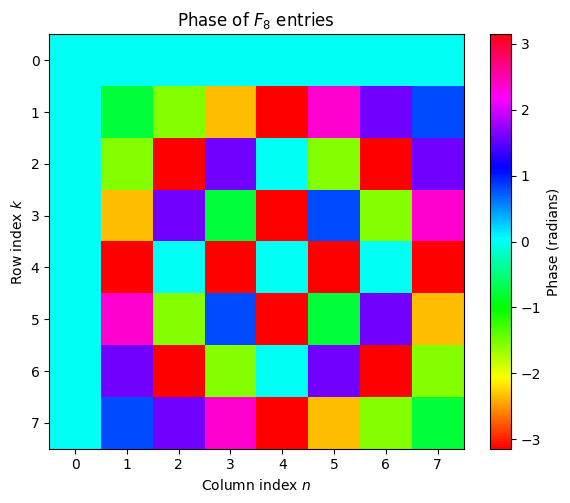

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.angle(F8), cmap='hsv', vmin=-np.pi, vmax=np.pi)
plt.colorbar(im, ax=ax, label='Phase (radians)')
ax.set_title(r'Phase of $F_8$ entries')
ax.set_xlabel('Column index $n$')
ax.set_ylabel('Row index $k$')
ax.set_xticks(range(N))
ax.set_yticks(range(N))
plt.tight_layout()
plt.show()

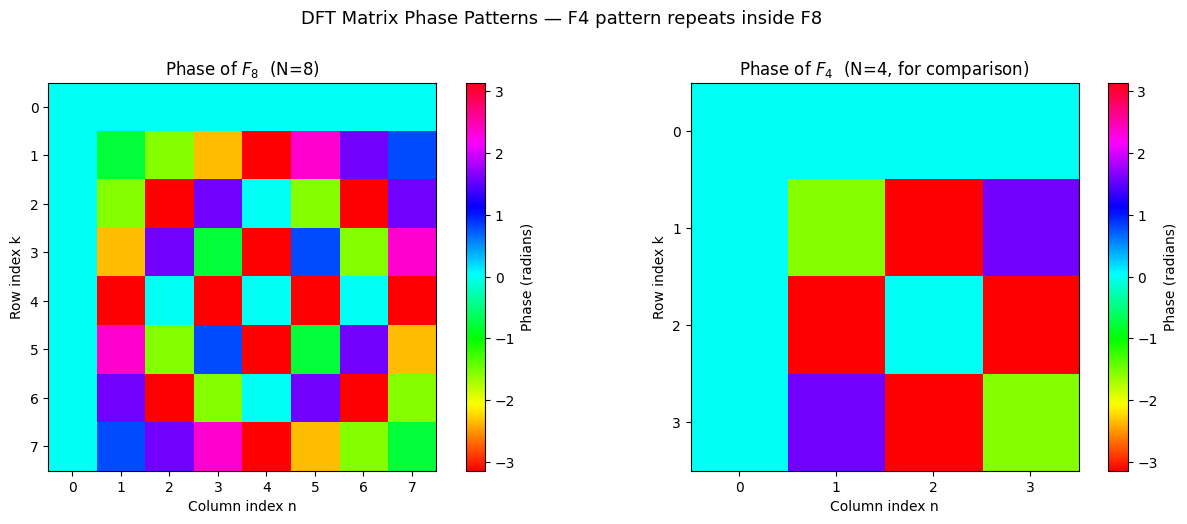

Look at row 2 of F8 (left image, k=2):
  The color pattern repeats exactly after 4 columns.
  This is the same pattern as row 2 of F4 (right image).
  F4 is hiding inside F8 — this is what the FFT exploits!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title, sz in zip(
        axes,
        [F8, F4],
        [r'Phase of $F_8$  (N=8)', r'Phase of $F_4$  (N=4, for comparison)'],
        [N, N4]):
    im = ax.imshow(np.angle(mat), cmap='hsv', vmin=-np.pi, vmax=np.pi)
    plt.colorbar(im, ax=ax, label='Phase (radians)')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Column index n')
    ax.set_ylabel('Row index k')
    ax.set_xticks(range(sz))
    ax.set_yticks(range(sz))

plt.suptitle('DFT Matrix Phase Patterns — F4 pattern repeats inside F8', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Look at row 2 of F8 (left image, k=2):")
print("  The color pattern repeats exactly after 4 columns.")
print("  This is the same pattern as row 2 of F4 (right image).")
print("  F4 is hiding inside F8 — this is what the FFT exploits!")

---
### DFT as Matrix-Vector Multiplication

Up to now we’ve mostly **looked at the DFT matrix** (its phase patterns, repeated structure, etc.). Next we’ll **apply** the DFT the most direct way: as a **matrix–vector multiplication**. That’s why the next cell is coded it’s a small computational check that connects the pictures to an actual spectrum (and it also shows the *butterfly* recombination that the FFT uses).

**Before you run the next cell, make a prediction.** For the length‑8 alternating signal

\[
 x = [1,0,1,0,1,0,1,0]
\]

where do you expect the **peaks** (largest magnitudes) to appear in the DFT output \(X[k]\) for \(k=0...7\)? Do you expect the biggest peak near **low frequencies** (near k=0) or **higher frequencies** (near k=N/2)? Write down your guess *and a one‑sentence reason*.


Now run the next cell and compare the result to your prediction.

In [ ]:
# Example: a periodic signal that alternates 1 and 0
import numpy as np

# Define the missing variables
N = 8  # Total number of points
N2 = N // 2  # Half the number of points (4)

# Define omega (the principal Nth root of unity)
omega = np.exp(-2j * np.pi / N)

# Define DFT matrices correctly
# F4 is a 4x4 DFT matrix
F4 = np.array([[np.exp(-2j * np.pi * i * j / N2) for j in range(N2)] for i in range(N2)])

# F8 is an 8x8 DFT matrix
F8 = np.array([[np.exp(-2j * np.pi * i * j / N) for j in range(N)] for i in range(N)])

# Original code
x = np.array([1, 0, 1, 0, 1, 0, 1, 0], dtype=complex)

x_even = x[0::2]   # (x0, x2, x4, x6)
x_odd  = x[1::2]   # (x1, x3, x5, x7)

# 4-point DFTs of even and odd subsequences
E = F4 @ x_even
O = F4 @ x_odd

# Twiddle factors W_k = omega^k for k = 0..3
W = np.array([np.exp(-2j * np.pi * k / N) for k in range(N2)])

# Butterfly recombination
X_butterfly = np.zeros(N, dtype=complex)
X_butterfly[:N2] = E + W * O
X_butterfly[N2:] = E - W * O

X_reference = F8 @ x

print("Butterfly result:")
print(np.round(X_butterfly, 6))
print("\nDirect DFT (F8 @ x):")
print(np.round(X_reference, 6))
print("\nMatch:", np.allclose(X_butterfly, X_reference))
print()
print("Only k=0 and k=4 are nonzero: the signal has energy only at those two frequencies.")
print("k=0 is the DC average (the signal averages to 0.5).")
print("k=4 is the alternating pattern (period 2 in a length-8 signal).")

Butterfly result:
[ 4.+0.j -0.-0.j  0.-0.j  0.-0.j  4.+0.j -0.-0.j  0.-0.j  0.-0.j]

Direct DFT (F8 @ x):
[ 4.+0.j -0.-0.j  0.-0.j  0.-0.j  4.+0.j -0.-0.j  0.-0.j -0.-0.j]

Match: True

Only k=0 and k=4 are nonzero: the signal has energy only at those two frequencies.
k=0 is the DC average (the signal averages to 0.5).
k=4 is the alternating pattern (period 2 in a length-8 signal).


> **Key takeaway:** The DFT is a linear transformation that a matrix-vector product with complexity $O(N^2)$. The QFT implements the *same* matrix using quantum gates. The FFT *factorizes* the same matrix into structured sparse components, reducing cost to $O(N \log N)$. Neither changes the result only the efficiency.
>
> *The FFT does not change the DFT matrix. It factorizes it into structured components that can be computed efficiently.*

---
## Hidden Structure in $F_8$

### Why Does Periodicity Matter?

Look closely at **row 2** of $F_8$. Its entries are powers of $\omega^2$:

$$\text{Row 2} = (1,\ \omega^2,\ \omega^4,\ \omega^6,\ \omega^8,\ \omega^{10},\ \omega^{12},\ \omega^{14})$$

Reducing mod 8 (since $\omega^8 = 1$):

$$\text{Row 2} = (1,\ \omega^2,\ \omega^4,\ \omega^6,\ 1,\ \omega^2,\ \omega^4,\ \omega^6)$$

It **repeats after 4 entries**. Why? Because:
$$\omega^{2(n+4)} = \omega^{2n} \cdot \omega^8 = \omega^{2n} \cdot 1 = \omega^{2n}$$

Furthermore, $\omega^2 = e^{-2\pi i / 4}$ — this is *exactly* the root of unity for an $N=4$ DFT. So:

$$\boxed{\text{Squaring an } N\text{th root of unity produces an } (N/2)\text{th root of unity.}}$$

This self-similarity is the mathematical engine behind the FFT recursion.

---
## Even/Odd Reordering Reveals the Block Structure

### The Key Idea

We just saw that $\omega^2$ (the square of the 8-point root) is the 4-point root. This means: if we separate **even-indexed inputs** $(x_0, x_2, x_4, x_6)$ from **odd-indexed inputs** $(x_1, x_3, x_5, x_7)$, each group undergoes a 4-point DFT, and the results can be combined cheaply.

**Reordering inputs = reordering columns of $F_8$.**
The DFT values do not change only how we organize the computation.

- Natural order: $(x_0, x_1, x_2, x_3, x_4, x_5, x_6, x_7)$
- Reordered:     $(x_0, x_2, x_4, x_6 \mid x_1, x_3, x_5, x_7)$

This permutes the columns of $F_8$ from $[0,1,2,3,4,5,6,7]$ to $[0,2,4,6,1,3,5,7]$.

Column order change:
  Natural:  [0, 1, 2, 3, 4, 5, 6, 7]
  Permuted: [0, 2, 4, 6, 1, 3, 5, 7]
  (Even indices first, then odd indices)



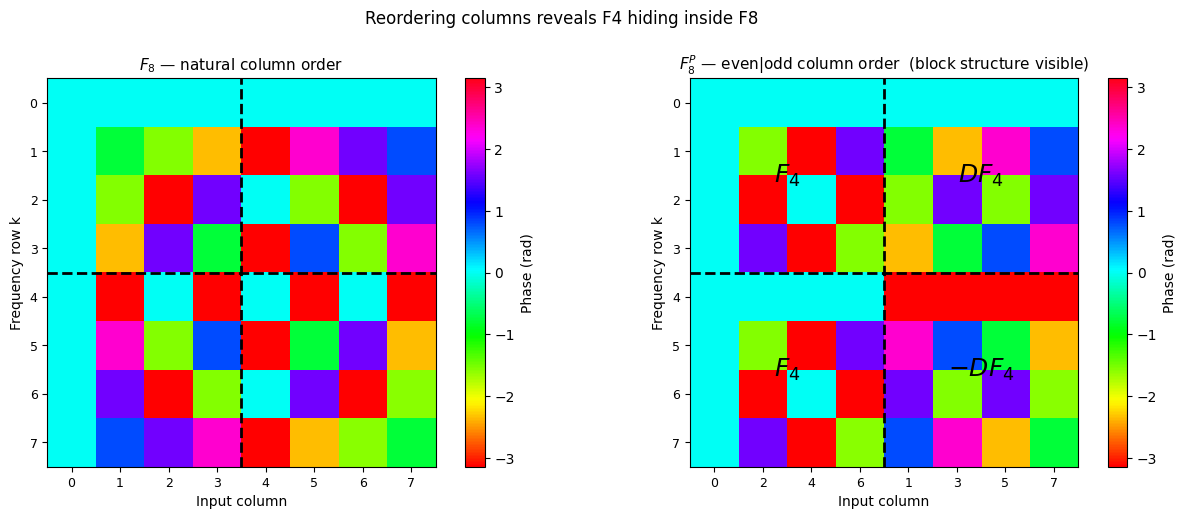

In [ ]:
# ── Permute columns: even indices first, then odd ─────────────────────
perm = [0, 2, 4, 6, 1, 3, 5, 7]
F8P  = F8[:, perm]   # same rows — only column order changes

print("Column order change:")
print("  Natural:  [0, 1, 2, 3, 4, 5, 6, 7]")
print("  Permuted:", perm)
print("  (Even indices first, then odd indices)")
print()

# Side-by-side phase heatmaps
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title, col_labels in zip(
        axes,
        [F8, F8P],
        [r'$F_8$ — natural column order',
         r'$F_8^P$ — even|odd column order  (block structure visible)'],
        [list(range(8)), perm]):
    im = ax.imshow(np.angle(mat), cmap='hsv', vmin=-np.pi, vmax=np.pi)
    plt.colorbar(im, ax=ax, label='Phase (rad)')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Input column')
    ax.set_ylabel('Frequency row k')
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticklabels(range(N), fontsize=9)
    ax.axvline(3.5, color='black', lw=2, linestyle='--')
    ax.axhline(3.5, color='black', lw=2, linestyle='--')

# Label the four blocks on the permuted matrix
axes[1].text(1.5, 1.5, r'$F_4$',       color='black', fontsize=18, ha='center', va='center', fontweight='bold')
axes[1].text(5.5, 1.5, r'$D F_4$',     color='black', fontsize=18, ha='center', va='center', fontweight='bold')
axes[1].text(1.5, 5.5, r'$F_4$',       color='black', fontsize=18, ha='center', va='center', fontweight='bold')
axes[1].text(5.5, 5.5, r'$- D F_4$',    color='black', fontsize=18, ha='center', va='center', fontweight='bold')

plt.suptitle('Reordering columns reveals F4 hiding inside F8', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

The diagonal stripes of repeating phase confirm the periodicity modulo 8. Notice that row 2 repeats every 4 entries — because $\omega^2$ is a 4th root of unity. This self-similarity is precisely what the FFT exploits when it splits even- and odd-indexed inputs.



**Why do two copies of $F_4$ appear?**

> *Even-indexed columns ($n = 2m$) have entries $\omega^{k \cdot 2m} = (\omega^2)^{km}$ — exactly the $F_4$ pattern. Both the upper half (k=0..3) and lower half (k=4..7) of the output share the same two size-4 sub-transforms. We compute each once and reuse.*

**Why does the diagonal twiddle matrix $D$ appear?**

> *Odd-indexed columns ($n = 2m+1$) contribute $\omega^{k(2m+1)} = \omega^k \cdot (\omega^2)^{km}$. The extra $\omega^k$ factor, different for each row $k$, is the diagonal of $D$.*

**Why does the minus sign appear in the lower-right block?**

> *For rows $k = 4, 5, 6, 7$, the twiddle factor is $\omega^k$ where $k \geq 4$. Writing $k = j+4$ (with $j = 0..3$): $\omega^{j+4} = \omega^j \cdot \omega^4 = \omega^j \cdot (-1) = -\omega^j$. The lower block's twiddle is the negative of the upper block's.*

---
## The Polynomial Connection

### A Familiar Trick

The even/odd split we just did is identical to a technique used in fast polynomial evaluation.

Let $A(x) = a_0 + a_1 x + a_2 x^2 + \cdots + a_7 x^7$.

Separate even and odd powers:

$$A(x) = \underbrace{(a_0 + a_2 x^2 + a_4 x^4 + a_6 x^6)}_{A_{\text{even}}(x^2)} + x \cdot \underbrace{(a_1 + a_3 x^2 + a_5 x^4 + a_7 x^6)}_{A_{\text{odd}}(x^2)}$$

So: $A(x) = A_{\text{even}}(x^2) + x \cdot A_{\text{odd}}(x^2)$

Now evaluate at $x = \omega^k$:

$$A(\omega^k) = A_{\text{even}}((\omega^2)^k) + \omega^k \cdot A_{\text{odd}}((\omega^2)^k) = E_k + \omega^k O_k$$

This is exactly the butterfly formula. FFT recursion is mathematically identical to even/odd polynomial splitting.

In [ ]:
# ── Verify the polynomial identity A(omega^k) = A_even + omega^k * A_odd ──
rng = np.random.default_rng(42)
a = rng.standard_normal(N) + 1j * rng.standard_normal(N)   # random coefficients

# Method 1: evaluate A(omega^k) directly for each k = 0..7
eval_pts = omega ** np.arange(N)
A_direct = np.array([np.polyval(a[::-1], w) for w in eval_pts])

# Method 2: even/odd split — A(x) = A_even(x^2) + x * A_odd(x^2)
a_even = a[0::2]   # coefficients a0, a2, a4, a6
a_odd  = a[1::2]   # coefficients a1, a3, a5, a7

A_split = np.array([
    np.polyval(a_even[::-1], w**2) + w * np.polyval(a_odd[::-1], w**2)
    for w in eval_pts
])

print("Direct evaluation A(omega^k):     ", np.round(A_direct[:4], 4), "...")
print("Even/odd split A_even + w*A_odd:  ", np.round(A_split[:4],  4), "...")
print()
print("Identity holds for all k :", np.allclose(A_direct, A_split))
print()
print("Conclusion: evaluating a polynomial at roots of unity via even/odd splitting")
print("is exactly the FFT butterfly.")

Direct evaluation A(omega^k):      [-2.4859+1.5888j  1.7217-4.3374j -2.1689+1.6688j  2.3045+2.0235j] ...
Even/odd split A_even + w*A_odd:   [-2.4859+1.5888j  1.7217-4.3374j -2.1689+1.6688j  2.3045+2.0235j] ...

Identity holds for all k : True

Conclusion: evaluating a polynomial at roots of unity via even/odd splitting
is exactly the FFT butterfly.



**Why is the FFT not a new transform?**

> *The FFT computes exactly the same values $X_k = \sum x_n \omega^{kn}$ as the DFT. It is a smarter organization of the same computation reusing sub-results rather than recomputing them.*

**What property of roots of unity enables the recursion?**

> *$\omega^N = 1$ (periodicity) and the self-similarity: $\omega^2$ is the $(N/2)$th root of unity. Squaring the root shrinks the problem. This enables halving at every level.*

**Why does complexity become $O(N \log N)$?**

> *Each recursion level does $O(N)$ work (combining the two half-size DFTs via the butterfly). There are $\log_2 N$ levels when $N$ is a power of 2. Total: $O(N \log N)$.*

**Why does this work especially cleanly when $N$ is a power of 2?**

> *When $N = 2^n$, the even/odd split halves the problem perfectly at every level all the way down to size-1 transforms (which are trivial: the DFT of a single number is itself). For prime $N$, this simple halving recursion is not directly available.*

---
## Twiddle Factors as Phase Shifts — Bridge to the QFT


Each twiddle factor is a rotation by angle $-2\pi k / N$. The FFT butterfly applies these rotations to the odd sub-DFT before recombination.


This is the core link to the **Quantum Fourier Transform**:


| Classical FFT | Quantum QFT |
|---|---|
| Multiply by $e^{-2\pi i k/N}$ | Apply controlled phase rotation |
| Phase shift in complex plane | Phase shift in quantum amplitude |
| Rotation of complex vector | Rotation of quantum phase |

Twiddle factors are classical phase shifts. They rotate complex numbers on the unit circle. In the QFT, controlled phase gates perform the same type of rotation, but on quantum amplitudes instead of classical numbers.

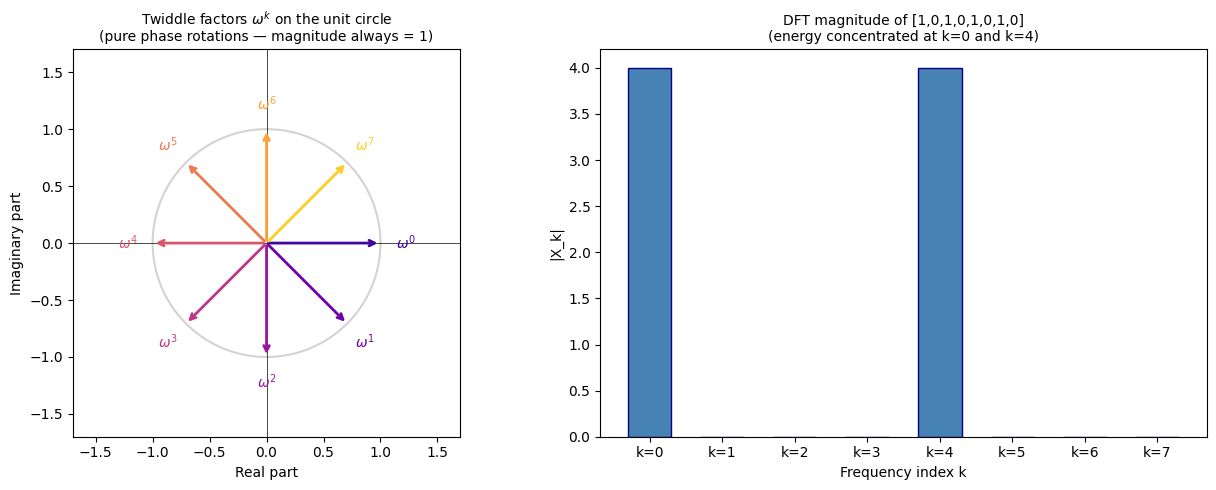

The periodic signal concentrates its energy at k=0 (DC) and k=4 (period-2 oscillation).
This is how the Fourier transform detects periodic structure. A key concept for the QFT.


In [ ]:
# ── Twiddle factors on the unit circle + DFT magnitude bar chart ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: all 8 twiddle factors as arrows on the unit circle
ax = axes[0]
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color='lightgray', lw=1.5)

W_all = omega ** np.arange(N)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, N))
for k_idx, (w, c) in enumerate(zip(W_all, colors)):
    ax.annotate('', xy=(w.real, w.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.0))
    ax.text(w.real * 1.22, w.imag * 1.22,
            rf'$\omega^{k_idx}$', ha='center', va='center', fontsize=10, color=c)

ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_aspect('equal')
ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.7, 1.7)
ax.set_title('Twiddle factors $\\omega^k$ on the unit circle\n(pure phase rotations — magnitude always = 1)', fontsize=10)
ax.set_xlabel('Real part')
ax.set_ylabel('Imaginary part')

# Right: DFT output magnitudes for the periodic test signal
ax2 = axes[1]
X_out = F8 @ np.array([1, 0, 1, 0, 1, 0, 1, 0], dtype=complex)
bars = ax2.bar(range(N), np.abs(X_out), color='steelblue', edgecolor='navy', width=0.6)
ax2.set_title('DFT magnitude of [1,0,1,0,1,0,1,0]\n(energy concentrated at k=0 and k=4)', fontsize=10)
ax2.set_xlabel('Frequency index k')
ax2.set_ylabel('|X_k|')
ax2.set_xticks(range(N))
ax2.set_xticklabels([f'k={i}' for i in range(N)])

plt.tight_layout()
plt.show()

print("The periodic signal concentrates its energy at k=0 (DC) and k=4 (period-2 oscillation).")
print("This is how the Fourier transform detects periodic structure. A key concept for the QFT.")

# Classial Computing Questions

In [ ]:
# @title Question 1
ask_mcq(
    "dft_q1",
    "In the DFT, what is ω (omega)?",
    [
        "A real number that scales the input signal",
        "A complex Nth root of unity: ω = e^{-2πi/N}",
        "A random phase chosen for each k",
        "A matrix used only in the FFT"
    ]
)

HTML(value="<b style='font-size:24px'>In the DFT, what is ω (omega)?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('A real number that scales the…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 2
ask_mcq(
    "q1",
    "What does the DFT do?",
    ["Compresses data by removing noise", "Converts a discrete signal from time domain to frequency domain", "Solves linear systems of equations","Randomizes signal phases"]
)

HTML(value="<b style='font-size:24px'>What does the DFT do?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Compresses data by removing n…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 3
ask_mcq(
    "q2",
    "What mathematical idea does FFT take advantage of?",
    ["Matrix inversion", "Random sampling", "Even function symmetry and divide-and-conquer", "Numerical integration"]
)




HTML(value="<b style='font-size:24px'>What mathematical idea does FFT take advantage of?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Matrix inversion', 'Random sa…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 4
ask_mcq(
    "q3",
    "Why do we use FFT over DFT?",
    ["It uses less memory only", "It provides exact symbolic answers", "It is computationally faster","It works only for analog signals"]
)



HTML(value="<b style='font-size:24px'>Why do we use FFT over DFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('It uses less memory only', 'I…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 5
ask_mcq(
    "q4",
    "What is the runtime of DFT and of FFT?",
    ["DFT: O(n), FFT: O(nlog⁡n)", "DFT: O(n^2), FFT: O(nlog⁡n)", "DFT: O(log⁡n), FFT: O(n^2)","DFT: O(nlog⁡n), FFT: O(n^2)"]
)



HTML(value="<b style='font-size:24px'>What is the runtime of DFT and of FFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('DFT: O(n), FFT: O(nlog\u2061n…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 6
ask_mcq(
    "q5",
    "What does the Inverse Fourier Transform do?",
    ["Removes high frequencies", "Converts frequency-domain data back to the original time-domain signal", "Squares all amplitudes","Encrypts the signal"]
)

HTML(value="<b style='font-size:24px'>What does the Inverse Fourier Transform do?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Removes high frequencies', 'C…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 7
ask_mcq(
    "dft_q7",
    "When splitting even/odd indices for the FFT of an N=8 DFT, the subproblems use which root of unity?",
    [
        "ω^2, which is the (N/2)-th root of unity",
        "ω^3, which is the (N/3)-th root of unity",
        "ω^8, which is always 0",
        "No root of unity is used in FFT"
    ]
)

HTML(value="<b style='font-size:24px'>When splitting even/odd indices for the FFT of an N=8 DFT, the subproble…

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('ω^2, which is the (N/2)-th ro…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 8
ask_mcq(
    "dft_q3",
    "In the DFT matrix F_N, why is row 0 all ones?",
    [
        "Because ω = 1 for every N",
        "Because ω^{0·n} = 1 for all n, so X_0 is the sum (DC component)",
        "Because row 0 represents the highest frequency",
        "Because row 0 is always removed in FFT"
    ]
)

HTML(value="<b style='font-size:24px'>In the DFT matrix F_N, why is row 0 all ones?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Because ω = 1 for every N', '…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 9
ask_mcq(
    "dft_q8",
    "In the FFT, what do 'twiddle factors' represent?",
    [
        "Random noise added to stabilize computation",
        "Phase rotations (complex exponentials) used when recombining odd/even results",
        "A way to sort inputs into increasing order",
        "A rule that forces outputs to be real numbers"
    ]
)

HTML(value="<b style='font-size:24px'>In the FFT, what do 'twiddle factors' represent?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Random noise added to stabili…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

# The Quantum Fourier Transform

## The Quantum Fourier Transform

The Quantum Fourier Transform (QFT) is a quantum algorithm that performs a Fourier transform on quantum amplitudes.
###Definition

The QFT acts on an $n$-qubit quantum state and is defined as:

$$\text{QFT} |{x}⟩ = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i xk/N} |{k}⟩$$

where $N = 2^n$ and $x \in \{0, 1, \ldots, N-1\}$.


Note on sign convention:

In classical signal processing, the DFT often uses a negative exponent.
In quantum computing, the QFT is typically defined with a positive exponent.
These differ by complex conjugation and do not affect algorithmic correctness.
###Matrix Form

The $QFT$ can also be represented as an $N \times N$ unitary matrix:

$$
\text{QFT}_N =
\frac{1}{\sqrt{N}}
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
1 & \omega & \omega^2 & \cdots & \omega^{N-1} \\
1 & \omega^2 & \omega^4 & \cdots & \omega^{2(N-1)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \omega^{N-1} & \omega^{2(N-1)} & \cdots & \omega^{(N-1)^2}
\end{pmatrix},
$$

where $\omega = e^{2\pi i/N}$ is a primitive $N$-th root of unity. More generally, the entries of the matrix are given by

$$
(\text{QFT}_N)_{j,k} = \frac{1}{\sqrt{N}} \omega^{jk}
= \frac{1}{\sqrt{N}} e^{2\pi i jk / N}.
$$ where $j$ and $k$ are the rows and columns of the matrix

If we review what the $DFT$ matrix looks like,

$$
\mathbf{DFT}_N =
\frac{1}{\sqrt{N}}
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
1 & \omega_N & \omega_N^2 & \cdots & \omega_N^{N-1} \\
1 & \omega_N^2 & \omega_N^4 & \cdots & \omega_N^{2(N-1)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \omega_N^{N-1} & \omega_N^{2(N-1)} & \cdots & \omega_N^{(N-1)^2}
\end{pmatrix},
$$

We can see that we get exactly the same matrix! QFT is just DFT but implemented with quantum gates. Conceptually, the DFT, FFT and QFT all do the same thing, transform an input vector from one basis state to another.

Key Properties of QFT

- **Unitary**: $\text{QFT}^\dagger \text{QFT} = I$
- **Reversible**: The inverse QFT is given by $\text{QFT}^{-1} = \text{QFT}^\dagger$


In [ ]:

# @title Question 6
ask_mcq(
    "q6",
    "The matrix representation of DFT and QFT are:",
    ["Very different", "The same", "Slighty different"]
)

HTML(value="<b style='font-size:24px'>The matrix representation of DFT and QFT are:</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Very different', 'The same', …

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

## Gate Implementation

Lets now look at what gates are used to implement the QFT and how these gates create the rotations needed.
1. **Hadamard Gate**

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

This creates a superposition of the computational basis states.

2. **Controlled Phase Rotations**

$$\text{CP}(\theta) = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & e^{i\theta} \end{pmatrix}$$

This creates a phase rotation when both the control and target qubits are $1$

The $H$ and $CP$ gates apply phase rotations to the qubits which parallels the rotations that the FFT applies.

Optionally $\text{SWAP}$ gates are also applied at the end

3. **Swap Gate**

$$
\text{SWAP} =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}
$$

The swap gates reverse the order of the qubits at the end of the QFT circuit.  
During the QFT, phases are accumulated from the most significant qubit to the least significant qubit, which results in the output qubits appearing in reversed (bit-reversed) order. The swap operations correct this by exchanging qubit positions so that the final state is expressed in the standard computational ordering.

In [ ]:
# @title Question 7
ask_mcq(
    "q7",
    "What three gates does the QFT primarily utilize?",
    ["Pauli-X, Pauli-Y, Pauli-Z", "CNOT, Toffoli, SWAP", "Hadamard, controlled phase rotations, SWAP", "Measurement, Pauli-X, reset"]
)

HTML(value="<b style='font-size:24px'>What three gates does the QFT primarily utilize?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Pauli-X, Pauli-Y, Pauli-Z', '…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

The phase factor angle can be rewritten to more explicitly show how it is calculated using a binary string.  
Using the fact that $N = 2^n$ the QFT formula can be expressed as the following:

$$
|x\rangle \rightarrow \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n-1} e^{\frac{2\pi i xk}{2^n}} |k\rangle
$$

Where the phase in this case is

$$
\theta = \frac{2\pi i xk}{2^n}.
$$

Let’s explore how to create this phase using quantum gates.

First let’s express $x$ in binary as:

$$
x = x_{n-1}2^{\,n-1} + x_{n-2}2^{\,n-2} + \cdots + x_0
$$

For example we can rewrite the number 5 as:

$$
5 = (101)_2 = 1\cdot2^2 + 0\cdot2^1 + 1\cdot2^0
$$

The next step is to divide $x$ by $(2^n)$:

$$
\frac{x}{2^n} = \frac{x_{n-1}}{2} + \frac{x_{n-2}}{2^2} + \cdots
+ \frac{x_0}{2^n}
$$

Notice that this expression is exactly the binary fraction

$$
\frac{x}{2^n} = 0.x_{n-1}x_{n-2}\dots x_0.
$$

Therefore we can replace $\frac{x}{2^n}$ in the phase term to get the result

$$
e^{2\pi i xk / 2^n} = e^{2\pi i k \left( \frac{x_{n-1}}{2} + \frac{x_{n-2}}{2^2} + \cdots + \frac{x_0}{2^n} \right)}
$$

This means now the phase is built up from the binary representation of each number. For example with the number 5 the phase would be calculated as:

$$
e^{2\pi i 5k / 2^3} = e^{2\pi i k  \left( \frac{1}{2} + \frac{0}{2^2} + \frac{1}{2^3} \right)}
$$

Because of the different powers in the denominator, each bit also contributes different amounts to the phase. Converting to binary also has one other key advantage: because binary is naturally split into powers of 2, this essentially mirrors the recursive structure of the FFT.

Most importantly, this binary fraction structure explains why the QFT output can be written as a tensor product of single-qubit states:

$$
|x_{n-1}\dots x_0\rangle
\longrightarrow
\bigotimes_{j=0}^{n-1}
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{2\pi i\, 0.x_{n-1}\dots x_{n-j}}
|1\rangle
\right).
$$

Here the symbol $\bigotimes$ means **tensor product**, which simply indicates that the overall state is built by combining individual single-qubit states.

For example, if one qubit is in state $|\phi\rangle$ and another is in state $|\psi\rangle$, then $|\phi\rangle \otimes |\psi\rangle$ represents the joint two-qubit state formed by combining them. In this case, the QFT output is written as a product of single-qubit states, meaning each qubit carries its own phase information.

The formula above shows that each output qubit picks up a phase determined by a binary fraction of the less significant bits of $x$, which is why the QFT circuit can be constructed using Hadamard gates followed by controlled phase rotations with angles that are powers of $1/2$.



## Full Calculation Walkthrough for $ QFT |5\rangle$

Using the definition:
$$\text{QFT} |{x}⟩ = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i xk/N} |{k}⟩$$
In this case $x=5$ and $N = 2^3 = 8$

Therefore:
$$\text{QFT} |{5}\rangle = \text{QFT} |{101}\rangle = \frac{1}{\sqrt{8}} \sum_{k=0}^{8-1} e^{2\pi i 5k/8} |{k}⟩$$

The following table shows the calculation for each value of $k$ and the phase associated with each $kth$ basis state.

$$
\begin{array}{c|c|c|c|c|c}
k & \text{basis state} & e^{\frac{2\pi i (5)k}{8}} & \text{simplified exponent} & \text{phase} & \text{phase and basis}\\
\hline
0 & |000\rangle & e^{\frac{2\pi i (5)(0)}{8}} & e^{0} & 0 & e^{0}|000\rangle\\
1 & |001\rangle & e^{\frac{2\pi i (5)(1)}{8}} & e^{i5\pi/4} & \frac{5\pi}{4}  & e^{i5\pi/4}|001\rangle \\
2 & |010\rangle & e^{\frac{2\pi i (5)(2)}{8}} & e^{i5\pi/2} & \frac{\pi}{2} & e^{i\pi/2}|010\rangle\\
3 & |011\rangle & e^{\frac{2\pi i (5)(3)}{8}} & e^{i15\pi/4} & \frac{7\pi}{4} & e^{i7\pi/4}|011\rangle\\
4 & |100\rangle & e^{\frac{2\pi i (5)(4)}{8}} & e^{i5\pi} & \pi & e^{\pi}|100\rangle\\
5 & |101\rangle & e^{\frac{2\pi i (5)(5)}{8}} & e^{i25\pi/4} & \frac{\pi}{4} & e^{i\pi/4}|101\rangle\\
6 & |110\rangle & e^{\frac{2\pi i (5)(6)}{8}} & e^{i15\pi/2} & \frac{3\pi}{2} & e^{i3\pi/2}|110\rangle\\
7 & |111\rangle & e^{\frac{2\pi i (5)(7)}{8}} & e^{i35\pi/4} & \frac{3\pi}{4} & e^{i3\pi/4}|111\rangle
\end{array}
$$

We use the fact that according to Euler's Formula $e^{i\theta} = \cos\theta + i\sin\theta$ to simplify phases. Because $cos$ and $sin$ are periodic functions we can use $e^{2\pi} = e^0 = 1$ to write the phases on the interval $[0,2\pi)$.

Adding each of the basis states together to form the state of the full quantum circuit we get:
$$
\frac{1}{\sqrt{8}}\Big(
|000\rangle
+ e^{i5\pi/4}|001\rangle
+ e^{i\pi/2}|010\rangle
+ e^{i7\pi/4}|011\rangle
+ e^{i\pi}|100\rangle
+ e^{i\pi/4}|101\rangle
+ e^{i3\pi/2}|110\rangle
+ e^{i3\pi/4}|111\rangle
\Big)
$$

In [ ]:
# @title Question 8
ask_mcq(
    "q8",
    "What does the QFT do?",
    ["Measures all qubits", "Performs classical convolution", "Maps computational basis states into phase-encoded superpositions (quantum frequency domain)", "Copies quantum states"]
)

HTML(value="<b style='font-size:24px'>What does the QFT do?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Measures all qubits', 'Perfor…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 9
ask_mcq(
    "q9",
    "Why do we rewrite x in binary when calculating the phase?",
    ["It is faster to calculate the angle", "It lets the phase be matched with the basis state", "It allows each bit to contribute a different amount to the phase", "It is easier for the quantum gate to apply the rotation"]
)

HTML(value="<b style='font-size:24px'>Why do we rewrite x in binary when calculating the phase?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('It is faster to calculate the…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

## Code Implementation
Now lets look at the code that actually implements QFT and see how the gates are applied. We will also apply the QFT to the state $|5\rangle$ and plot the amplitudes and phases to make sure they match with what was calculated above.

In [ ]:
# @title Initial Imports
!pip install -q qiskit
!pip install -q qiskit-aer
!pip install -q pylatexenc


import qiskit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
import numpy as np
%matplotlib inline

In [ ]:
# QFT code implementation used throughout notebook
def QFT(circuit, n):
  for i in reversed(range(n)):  # reverse for qiskit's qubit ordering
    # H gate
    circuit.h(i)

    # CP gates (reversed order compared to original)
    for k in range(i):
        theta = np.pi / (2 ** (i - k))
        circuit.cp(theta, i, k)  # i = control, k = target

  # SWAP gates
  for i in range(n // 2):
    circuit.swap(i, n - i - 1)

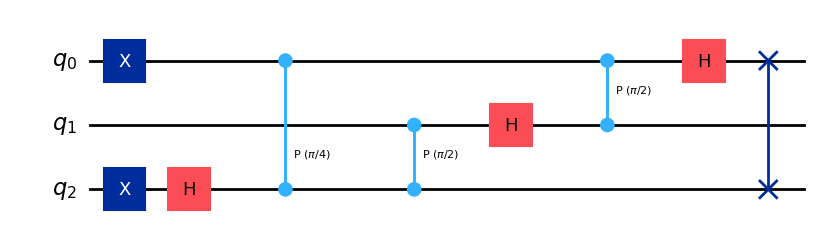

In [ ]:
qubits = "101"
n = len(qubits)
qubits = qubits[::-1]
qc = qiskit.QuantumCircuit(n) #when circuit is created all qubits are in the |0> state


for i in range(n): #flip qubits that are 1 in the input string to prepare the desired state
    if qubits[i] == "1":
        qc.x(i)

QFT(qc, n)

qc.draw(output="mpl")



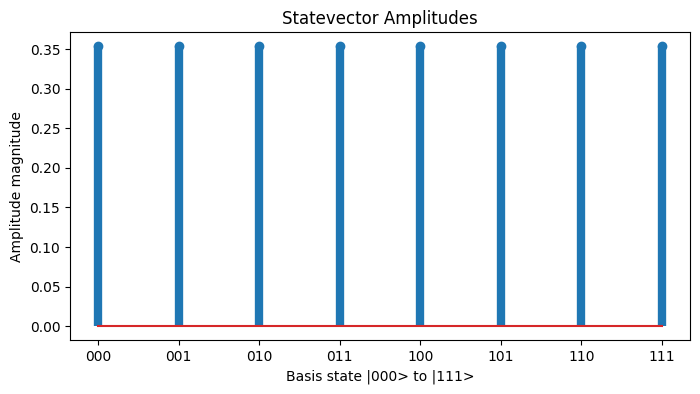

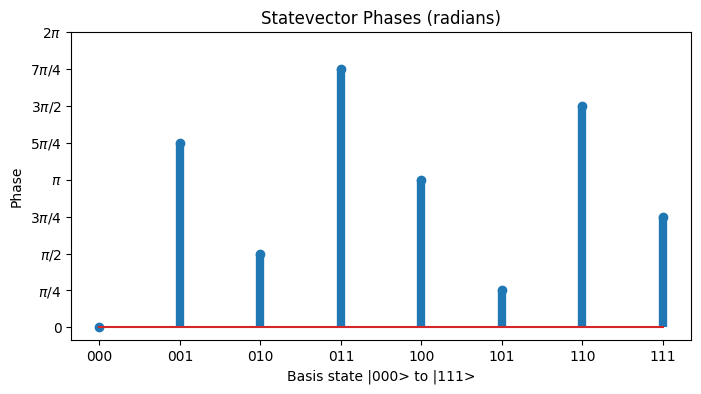

In [ ]:
# @title Generate Amplitude and Phase plots
# Get statevector
sv = Statevector.from_instruction(qc)
fs = 25
# Plot amplitudes (magnitudes)
plt.figure(figsize=(8,4))

markerline, stemlines, baseline = plt.stem(range(8), np.abs(sv.data))
plt.setp(stemlines, linewidth=6)
plt.title("Statevector Amplitudes")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Amplitude magnitude")
plt.xticks(range(8), [format(i,'03b') for i in range(8)])

plt.show()

# Plot phases
phases = np.angle(sv.data)
phases = np.mod(phases, 2*np.pi)   # convert to [0, 2π)

plt.figure(figsize=(8,4))

markerline, stemlines, baseline = plt.stem(range(8),phases)
plt.setp(stemlines, linewidth=6)


plt.title("Statevector Phases (radians)")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Phase")

plt.xticks(range(8), [format(i,'03b') for i in range(8)])

yticks = [
    0,
    np.pi/4,
    np.pi/2,
    3*np.pi/4,
    np.pi,
    5*np.pi/4,
    3*np.pi/2,
    7*np.pi/4,
    2*np.pi
]

ytick_labels = [
    '0',
    r'$\pi/4$',
    r'$\pi/2$',
    r'$3\pi/4$',
    r'$\pi$',
    r'$5\pi/4$',
    r'$3\pi/2$',
    r'$7\pi/4$',
    r'$2\pi$'
]

plt.yticks(yticks, ytick_labels)

plt.show()

As we can see from the plots, each basis state has equal amplitude which is consistant with the final state we got from our calculations. Also, if you check the phase associated with each basis state, you will see that they also match up.

## Runtime Complexity Comparison
For $N= 2^n$ components DFT, FFT, and QFT have the require the following number of operations:


*   DFT $O(N^2)$
*   FFT $O(NlogN)$
*   QFT $O(log^2N)$

As we can see, the QFT is exponentially faster than its classical counterparts.

Important: The QFT does not output the full Fourier vector.
Measurement yields only one basis state per run.
The speedup is meaningful only when QFT is embedded inside larger quantum algorithms (e.g., phase estimation, Shor).



In [ ]:
# @title Question 10
ask_mcq(
    "q10",
    "Rank the runtimes of QFT, DFT, and FFT",
    ["FFT < DFT < QFT","DFT < FFT < QFT", "QFT < DFT < FFT","DFT < QFT < FFT"]
)

HTML(value="<b style='font-size:24px'>Rank the runtimes of QFT, DFT, and FFT</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('FFT < DFT < QFT', 'DFT < FFT …

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

## FFT VS QFT Structural Comparison
$$
\begin{array}{|l|l|}
\hline
\text{Classical FFT} & \text{Quantum QFT} \\
\hline
\text{Even/odd split} & \text{Qubit-by-qubit decomposition} \\
\text{Twiddle factor} & \text{Controlled phase rotation} \\
\text{Recursive structure} & \text{Layered gate structure} \\
\text{Permutation} & \text{Swap gates} \\
\hline
\end{array} $$

The computational advantage of the FFT over the DFT comes from its recursive factorization, which reduces the original transform into smaller subproblems and reuses intermediate results. This factorization begins by separating the input into even and odd indexed components, thereby decomposing the DFT matrix into structured submatrices. In the QFT, this structure is mirrored through the binary encoding of the basis states. Rather than splitting the input vector explicitly, the QFT exploits the binary expansion of indices to decompose the phase into contributions from individual qubits.


In the FFT, phase factors are introduced during the recombination of the even and odd recursive branches. These factors take the form $e^{-2\pi i k/N}$ and represent structured phase rotations applied prior to recombination. In QFT, an equivalent phase accumulation is achieved through controlled phase gates, which construct the same exponential factors incrementally according to the binary fractions arising from $\frac{x}{2^n}$.

The recursive decomposition fundamental to the FFT reduces the original transform into smaller subproblems and is the core of the FFT’s speedup.  In QFT, this decomposition is reflected in the layered grouping structure of the circuit. Each group begins with a Hadamard gate applied to a qubit, followed by a sequence of controlled phase gates that accumulate the required phase contributions. In this way, recursive classical factorization is replaced by layered binary phase accumulation at the gate-level.

Some FFT implementations produce their outputs in reversed bit order requiring a permutation step at the end. In QFT, this permutation is also optionally implemented through a sequence of SWAP gates applied as the final step of the circuit, reflecting the same structural reordering of indices.

## Periodicity Case Study
Given a periodic input vector $V = [1,0,1,0,1,0,1,0]$ lets see the difference between computing the DFT and QFT of the vector.

Predict before running: Where do you expect peaks? Why?

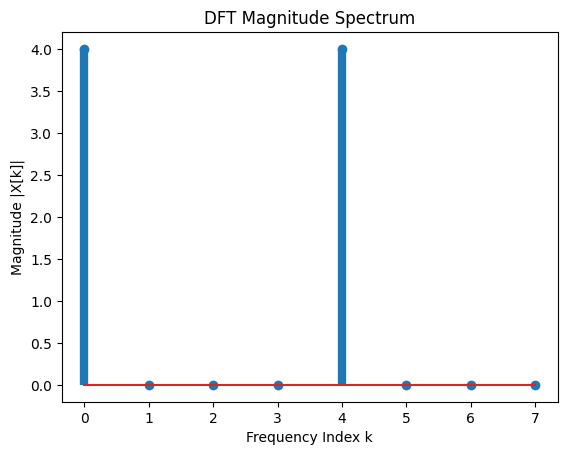

In [ ]:
# @title DFT Magnitude Plot
import numpy as np
import matplotlib.pyplot as plt

# Example input vector
x = np.array([1, 0,1,0,1,0,1,0])

# Compute the DFT
X = np.fft.fft(x)

# Compute magnitudes
magnitudes = np.abs(X)

# Frequency indices
k = np.arange(len(X))
fs = 25
# Plot magnitude spectrum
#plt.stem(k, magnitudes)
markerline, stemlines, baseline = plt.stem(range(8), magnitudes)

# Make all stems bold
plt.setp(stemlines, linewidth=6)
plt.xlabel("Frequency Index k" )
plt.ylabel("Magnitude |X[k]|")
plt.title("DFT Magnitude Spectrum")

plt.show()

Here we see peaks at frequencies 0 and 4. This suggests that periodicity in the input vector translates to concentrated energies at specific frequencies.

The equivalent form of this vector is the quantum superposition $|0\rangle + |2\rangle+ |4\rangle + |6\rangle$ since $V = [1,0,1,0,1,0,1,0]$ has a $1$ in the $0th$ and $2nd$ and $4th$ and $6th$ indices. Lets compute the QFT of this basis state and see the amplitudes and phases.

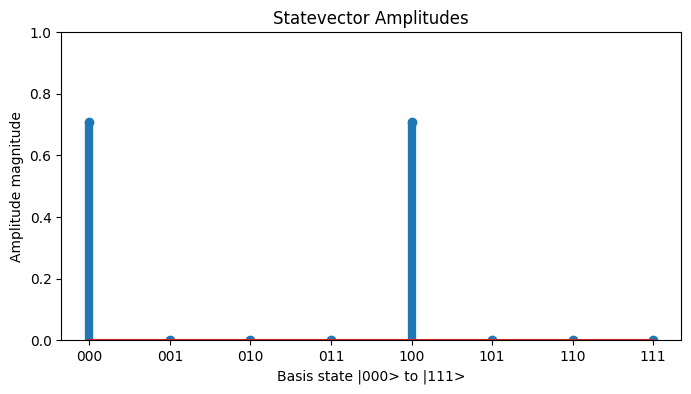

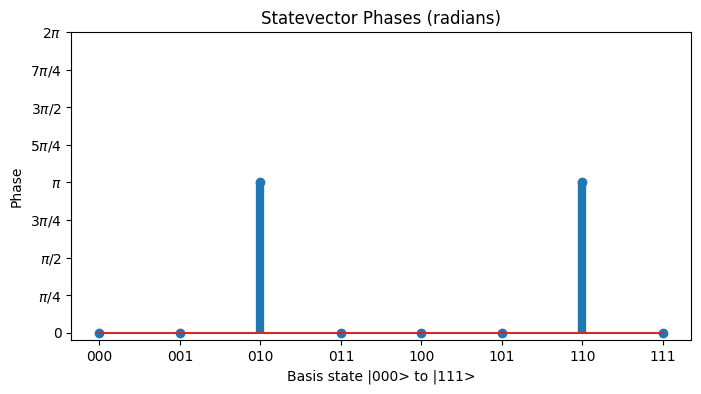

In [ ]:
# @title Amplitude and Phase Plots
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

figsize = (8,4)
fs = 20

# 3-qubit superposition |0> + |2> + |4> + |6>
amplitudes = [1/2, 0, 1/2, 0, 1/2, 0, 1/2, 0]

# Create circuit
qc = QuantumCircuit(3)
qc.initialize(amplitudes, [0,1,2])

# Apply QFT
QFT(qc, 3)

# Get statevector
sv = Statevector.from_instruction(qc)
amps = np.abs(sv.data)

# Plot
plt.figure(figsize=figsize)

markerline, stemlines, baseline = plt.stem(range(8), amps)
plt.setp(stemlines, linewidth=6)

plt.title("Statevector Amplitudes")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Amplitude magnitude")
plt.xticks(range(8), [format(i,'03b') for i in range(8)])

plt.ylim(0, 1)

plt.show()

# Plot phases
phases = np.angle(sv.data)
phases = np.mod(phases, 2*np.pi)   # convert to [0, 2π)

plt.figure(figsize=(8,4))
markerline, stemlines, baseline = plt.stem(range(8), phases)
plt.setp(stemlines, linewidth=6)

plt.title("Statevector Phases (radians)")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Phase")

plt.xticks(range(8), [format(i,'03b') for i in range(8)])

yticks = [
    0,
    np.pi/4,
    np.pi/2,
    3*np.pi/4,
    np.pi,
    5*np.pi/4,
    3*np.pi/2,
    7*np.pi/4,
    2*np.pi
]

ytick_labels = [
    '0',
    r'$\pi/4$',
    r'$\pi/2$',
    r'$3\pi/4$',
    r'$\pi$',
    r'$5\pi/4$',
    r'$3\pi/2$',
    r'$7\pi/4$',
    r'$2\pi$'
]

plt.yticks(yticks, ytick_labels)

plt.show()

Here we again see concentration at 0 and 4 this time at the basis states representing those numbers. We are only able to see exact amplitudes because we are using a quantum simulator, if this were run on a real quantum computer we would need to measure the circuit multiple times (giving us 1 basis state per measurement) and create a probability plot based on how many times we measure each basis state. Below is a table comparing DFT to QFT in terms of what their inputs are and what their outputs tell us.


$$
\begin{array}{|l|l|}
\hline
\textbf{Classical Fourier} & \textbf{Quantum Fourier} \\
\hline
\text{Input vector} & \text{Quantum superposition} \\
\text{DFT produces coefficients} & \text{QFT produces amplitudes} \\
\text{Magnitudes show frequency peaks} & \text{Measurement probabilities reflect those peaks} \\
\text{All coefficients visible} & \text{Only one sample per measurement} \\
\hline
\end{array}
$$

In [ ]:
# @title Question 11
ask_mcq(
    "q11",
    "How do the magnitudes after DFT and amplitudes after QFT compare?",
    ["They have peaks at the same points", "They have peaks at different points", "They cannot be compared"]
)

HTML(value="<b style='font-size:24px'>How do the magnitudes after DFT and amplitudes after QFT compare?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('They have peaks at the same p…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

## The Inverse Quantum Fourier Transform (IQFT)

The Inverse Quantum Fourier Transform (IQFT) reverses the operation of the QFT, transforming from the frequency domain back to the computational basis. It is the Hermitian adjoint (conjugate transpose) of the QFT.

###Definition

$$\text{IQFT} = \text{QFT}^{\dagger}$$

The IQFT acts on an $n$-qubit quantum state as:

$$\text{IQFT} |{k}⟩ = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} e^{-2\pi i xk/N} |{x}⟩$$
If you look closely, this is the same formula used to compute the QFT, just the sign of the exponential has been flipped to be negative.

**Key Property: Reversibility**

Just like with the Inverse Fourier Transform, if you apply the IQFT to a system after you have applied the QFT to it you get back the original state.

$$\text{IQFT}(\text{QFT}(|{\psi})⟩) = |{\psi}⟩$$

This makes the QFT/IQFT pair a useful tool for quantum algorithms - you can transform to the frequency domain, perform operations, and transform back.

### Implementation

The IQFT is implemented by:
1. Reversing the order of gates from the QFT
2. Using the **negative** of the phase angles in the controlled phase gates
3. The algorithm structure mirrors the QFT but with conjugated operations

Let's now implement the IQFT in code and apply it to our superposition from above to make sure we really do get back our initial state of $|0\rangle + |2\rangle+ |4\rangle + |6\rangle$

In [ ]:
# @title Question 12
ask_mcq(
    "q12",
    "What is the result of applying the inverse QFT?",
    ["It reverts the phases back to 0 without changing the amplitudes", "It negates the amplitudes of all basis states", "It converts the quantum system to an entirely new basis state","It reverts the system back to its state before the QFT was applied"]
)

HTML(value="<b style='font-size:24px'>What is the result of applying the inverse QFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('It reverts the phases back to…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
#IQFT code implementation

def IQFT(circuit, n):
    # SWAP gates (undo final permutation first)
    for i in range(n // 2):
        circuit.swap(i, n - i - 1)

    for i in range(n):
        # CP gates (reverse order with negative angles)
        for k in range(i):
            theta = -np.pi / (2 ** (i-k))
            circuit.cp(theta, i, k)

        # Hadamard
        circuit.h(i)

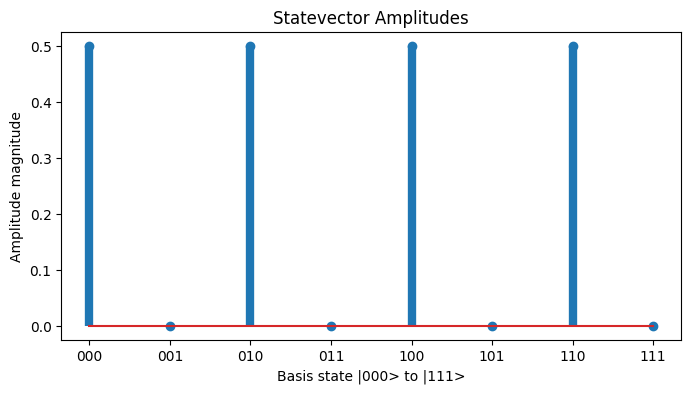

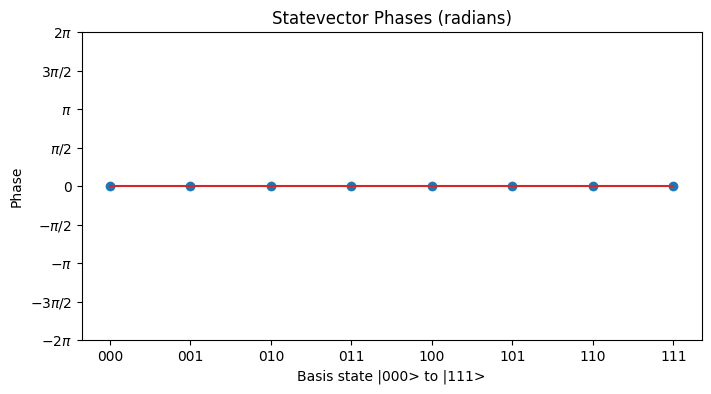

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


# 3-qubit superposition |0> + |2> + |4> + |6>
amplitudes = [1/2, 0, 1/2, 0, 1/2, 0, 1/2, 0]

# Create circuit
qc = QuantumCircuit(3)
qc.initialize(amplitudes, [0,1,2])


# Apply QFT
QFT(qc, 3)

# Apply IQFT
IQFT(qc,3)

# Get statevector
sv = Statevector.from_instruction(qc)

# Plot amplitudes (magnitudes)
plt.figure(figsize=(8,4))
markerline, stemlines, baseline = plt.stem(range(8), np.abs(sv.data))
plt.setp(stemlines, linewidth=6)
plt.title("Statevector Amplitudes")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Amplitude magnitude")
plt.xticks(range(8), [format(i,'03b') for i in range(8)])
plt.show()

# Plot phases
plt.figure(figsize=(8,4))
markerline, stemlines, baseline = plt.stem(range(8), np.angle(sv.data))
plt.setp(stemlines, linewidth=6)
plt.title("Statevector Phases (radians)")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Phase")
plt.xticks(range(8), [format(i,'03b') for i in range(8)])

yticks = [-2*np.pi, -3*np.pi/2, -np.pi, -np.pi/2, 0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
ytick_labels = [r'$-2\pi$', r'$-3\pi/2$', r'$-\pi$', r'$-\pi/2$', '0',
                r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
plt.yticks(yticks, ytick_labels)
plt.show()

As we can see all the phases have been reset to 0 and the amplitudes of our system are a equal super position of our initial state. This means the IQFT correctly reversed the action of the QFT.

## QFT Applications
The QFT has applications in many different quantum algorithms such as quantum machine learning, phase estimation, and most notably Shor's factoring algorithm.

Unfortunately despite the speedup the QFT offers over the DFT and the FFT, it is not a complete replacement for those other algorthims. When a quantum system is measured after the QFT is applied we only obtain one measurement result of one amplitude, not all the Fourier Coeffients like we do with FFT and DFT. Because of this the QFT is only really used as a subroutine inside other quantum algorithms, not as a seperate algorithm run by itself.

In [ ]:
# @title Question 13
ask_mcq(
    "q13",
    "What are some practical applications of QFT?",
    ["Image compression ", "Sorting classical array", "Period finding and phase estimation in quantum algorithms", "Classical database indexing"]
)

HTML(value="<b style='font-size:24px'>What are some practical applications of QFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Image compression ', 'Sorting…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 14
ask_mcq(
    "q14",
    "Why is QFT not a complete replacement for DFT?",
    ["QFT is slower than FFT in all cases", "QFT requires analog hardware", "QFT outputs amplitudes that cannot all be measured simultaneously", "QFT cannot compute phases"]
)

HTML(value="<b style='font-size:24px'>Why is QFT not a complete replacement for DFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('QFT is slower than FFT in all…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
# @title Question 15
ask_mcq(
    "q15",
    "Measuring a quantum state after QFT typically gives:",
    ["All Fourier coefficients", "Half the coefficients", "One sampled outcome", "No information"]
)

HTML(value="<b style='font-size:24px'>Measuring a quantum state after QFT typically gives:</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('All Fourier coefficients', 'H…

Button(button_style='success', description='Save answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio .p-Widget.jp-InputArea input[type="radio"] + label,\n    .big-radio …

In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

def export_pdf(filename="responses.pdf"):
    styles = getSampleStyleSheet()
    story = []

    story.append(Paragraph("Notebook Responses", styles["Heading1"]))
    story.append(Spacer(1, 20))

    for i, (_, data) in enumerate(responses.items(), 1):
        text = f"{i}. {data['question']}<br/>Answer: {data['selected']}"
        story.append(Paragraph(text, styles["BodyText"]))
        story.append(Spacer(1, 18))

    doc = SimpleDocTemplate(filename)
    doc.build(story)

    print(f"Saved to {filename}")


In [ ]:
from google.colab import files

btn = widgets.Button(description="Download PDF", button_style="primary")

def make_pdf(b):
    export_pdf()
    files.download("responses.pdf")

btn.on_click(make_pdf)
display(btn)


Button(button_style='primary', description='Download PDF', style=ButtonStyle())

Saved to responses.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Post Survey Link

https://forms.office.com/Pages/ResponsePage.aspx?id=2wING578lUSVNx03nMoq5-3BxI6hVGxAlNsUatNmSW1UMlEzQkc3T0FCN1lIQTFQMllJSFkzSEI2VC4u

#PDF Submission Link
https://forms.office.com/Pages/ResponsePage.aspx?id=2wING578lUSVNx03nMoq5_kvnGH0eMdLiU10jNlhf0ZUOUw3TlBYTjRWMlo5SDNTVzZFMlNPU0RDTy4u